**Basis Encoding**

In [1]:
from qiskit import QuantumCircuit

# Data point to encode
x = 5  # binary: 0101
y = 7  # binary: 0111
z = 0  # binary: 0000

# Convert each to 4-bit binary list
x_bits = [int(b) for b in format(x, "04b")]  # [0,1,0,1]
y_bits = [int(b) for b in format(y, "04b")]  # [0,1,1,1]
z_bits = [int(b) for b in format(z, "04b")]  # [0,0,0,0]

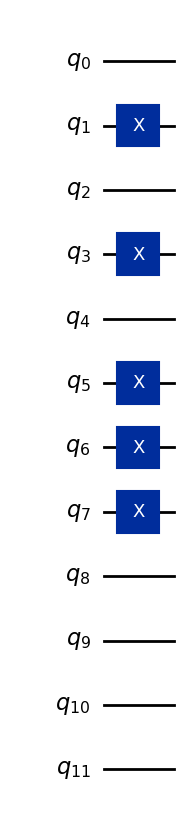

In [2]:
# Combine all bits
all_bits = x_bits + y_bits + z_bits  # [0,1,0,1,0,1,1,1,0,0,0,0]

# Initialize a 12-qubit quantum circuit
qc = QuantumCircuit(12)

# Apply x-gates where the bit is 1
for idx, bit in enumerate(all_bits):
    if bit == 1:
        qc.x(idx)

qc.draw("mpl")

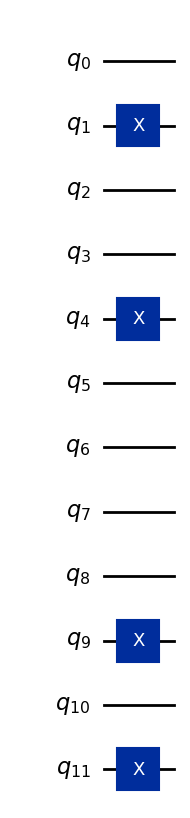

In [3]:
# TRY: (4, 8, 5)

x = 4
y = 8
z = 5

x_bits = [int(b) for b in format(x, "04b")]
y_bits = [int(b) for b in format(y, "04b")]
z_bits = [int(b) for b in format(z, "04b")]

all_bits = x_bits + y_bits + z_bits

qc = QuantumCircuit(12)

# Apply x-gates where the bit is 1
for idx, bit in enumerate(all_bits):
    if bit == 1:
        qc.x(idx)

qc.draw("mpl")

**Amplitude Encoding**

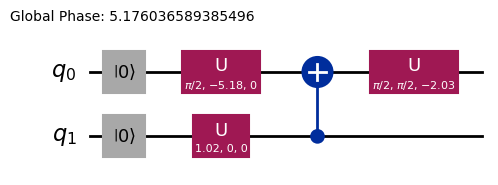

In [5]:
# (4, 8, 5)
# 4^2 + 8^2 + 5^2 = 16 + 64 + 25 = 105
# normalization condition: sqrt(105)

import math

desired_state = [
    1 / math.sqrt(105) * 4,
    1 / math.sqrt(105) * 8,
    1 / math.sqrt(105) * 5,
    1 / math.sqrt(105) * 0,
]

# features (N): 3
# num qubits (n): 2 --- 2^n = 4 >= 3 = N
# padding the extra with uninformative constants (zero)

qc = QuantumCircuit(2)
qc.initialize(desired_state, [0, 1])

qc.decompose(reps=5).draw(output="mpl")

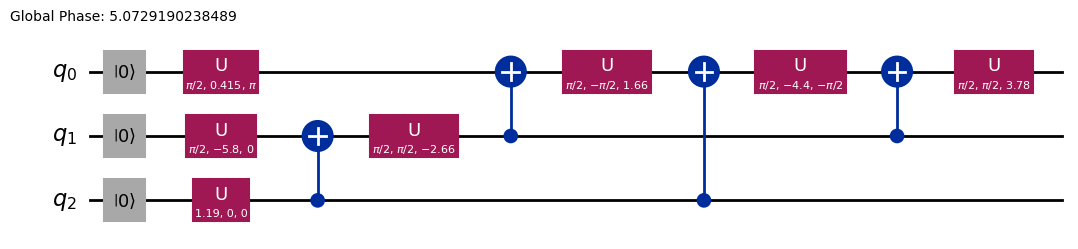

In [10]:
# TRY: (9, 8, 6, 2, 9, 2)
# N = 6 
# n = 3

x = [9, 8, 6, 2, 9, 2]

desired_state = [
    9 / math.sqrt(270), 
    8 / math.sqrt(270), 
    6 / math.sqrt(270), 
    2 / math.sqrt(270), 
    9 / math.sqrt(270), 
    2 / math.sqrt(270), 
    0,
    0,
]

qc = QuantumCircuit(3)
qc.initialize(desired_state, [0, 1, 2])

qc.decompose(reps=8).draw(output="mpl")

Normalized array:
[0.17342199 0.34684399 0.21677749 0.39019949 0.34684399 0.26013299
 0.086711   0.39019949 0.086711   0.21677749 0.30348849 0.
 0.1300665  0.30348849 0.21677749 0.        ]

[0, 1, 2, 3]


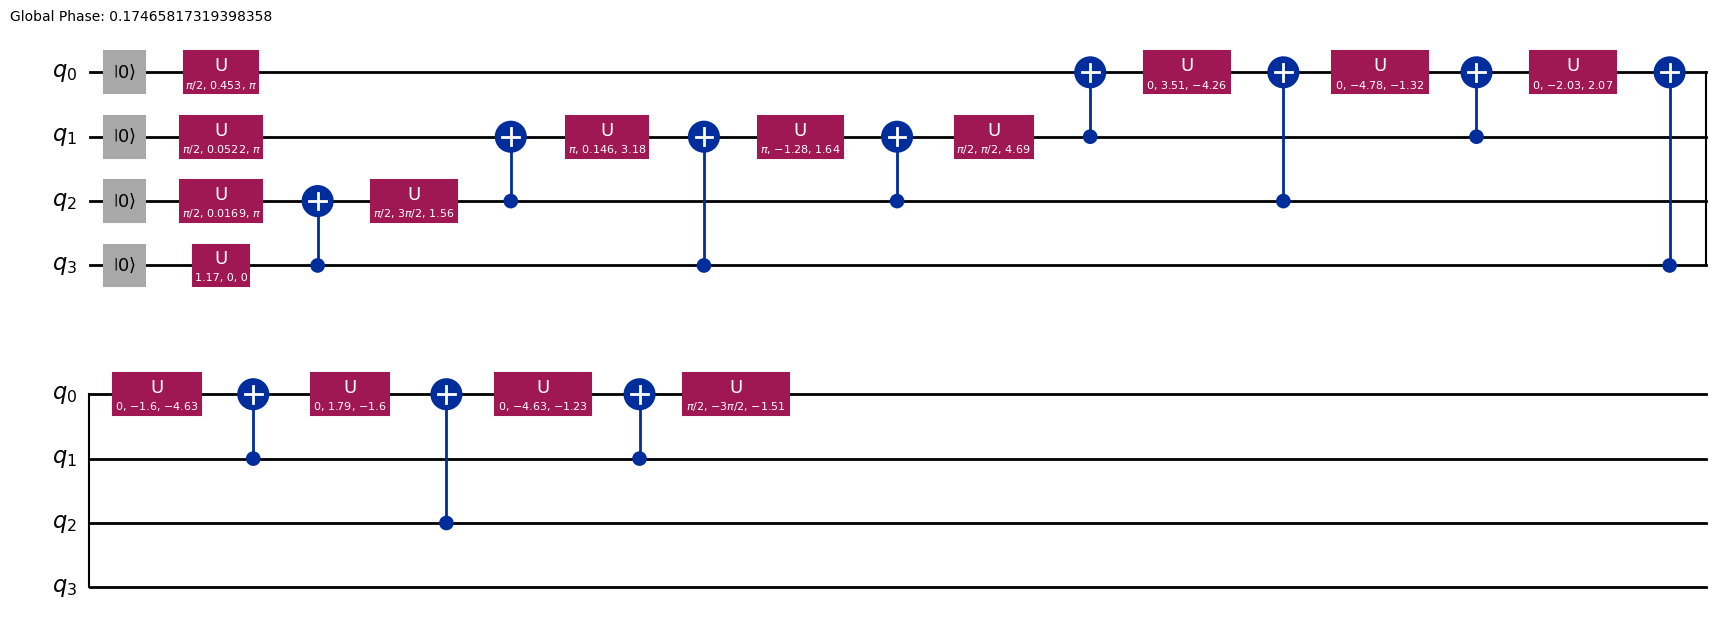

In [ ]:
import numpy as np
from math import sqrt

init_list = [4, 8, 5, 9, 8, 6, 2, 9, 2, 5, 7, 0, 3, 7, 5]
qubits = round(np.log(len(init_list)) / np.log(2) + 0.4999999999)
need_length = 2**qubits
pad = need_length - len(init_list)
for i in range(pad):
    init_list.append(0)

init_array = np.array(init_list)  # Unnormalized data vector
length = sqrt(
    sum(init_array[i] ** 2 for i in range(0, len(init_array)))
)  # Vector length
norm_array = init_array / length  # Normalized array
print("Normalized array:")
print(norm_array)
print()

qubit_numbers = []
for i in range(0, qubits):
    qubit_numbers.append(i)
print(qubit_numbers)

qc = QuantumCircuit(qubits)
qc.initialize(norm_array, qubit_numbers)
qc.decompose(reps=7).draw(output="mpl")

**Angle Encoding**

In [13]:
from qiskit.quantum_info import Statevector
from math import pi

qc = QuantumCircuit(1)
state1 = Statevector.from_instruction(qc)
qc.ry(pi / 2, 0)  # Phase gate rotates by an angle pi/2
state2 = Statevector.from_instruction(qc)
states = state1, state2

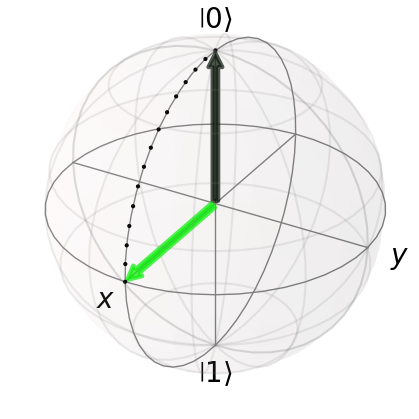

In [14]:
import numpy as np
from qiskit.visualization.bloch import Bloch
from qiskit.visualization.state_visualization import _bloch_multivector_data


def plot_Nstates(states, axis, plot_trace_points=True):
    """This function plots N states to 1 Bloch sphere"""
    bloch_vecs = [_bloch_multivector_data(s)[0] for s in states]

    if axis is None:
        bloch_plot = Bloch()
    else:
        bloch_plot = Bloch(axes=axis)

    bloch_plot.add_vectors(bloch_vecs)

    if len(states) > 1:

        def rgba_map(x, num):
            g = (0.95 - 0.05) / (num - 1)
            i = 0.95 - g * num
            y = g * x + i
            return (0.0, y, 0.0, 0.7)

        num = len(states)
        bloch_plot.vector_color = [rgba_map(x, num) for x in range(1, num + 1)]

    bloch_plot.vector_width = 3
    bloch_plot.vector_style = "simple"

    if plot_trace_points:

        def trace_points(bloch_vec1, bloch_vec2):
            # bloch_vec = (x,y,z)
            n_points = 15
            thetas = np.arccos([bloch_vec1[2], bloch_vec2[2]])
            phis = np.arctan2(
                [bloch_vec1[1], bloch_vec2[1]], [bloch_vec1[0], bloch_vec2[0]]
            )
            if phis[1] < 0:
                phis[1] = phis[1] + 2 * pi
            angles0 = np.linspace(phis[0], phis[1], n_points)
            angles1 = np.linspace(thetas[0], thetas[1], n_points)

            xp = np.cos(angles0) * np.sin(angles1)
            yp = np.sin(angles0) * np.sin(angles1)
            zp = np.cos(angles1)
            pnts = [xp, yp, zp]
            bloch_plot.add_points(pnts)
            bloch_plot.point_color = "k"
            bloch_plot.point_size = [4] * len(bloch_plot.points)
            bloch_plot.point_marker = ["o"]

        for i in range(len(bloch_vecs) - 1):
            trace_points(bloch_vecs[i], bloch_vecs[i + 1])

    bloch_plot.sphere_alpha = 0.05
    bloch_plot.frame_alpha = 0.15
    bloch_plot.figsize = [4, 4]

    bloch_plot.render()


plot_Nstates(states, axis=None, plot_trace_points=True)

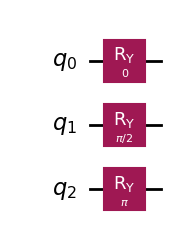

In [15]:
qc = QuantumCircuit(3)
qc.ry(0, 0)
qc.ry(2 * math.pi / 4, 1)
qc.ry(2 * math.pi / 2, 2)
qc.draw(output="mpl")

**Phase Encoding**

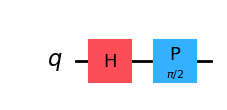

In [16]:
qc = QuantumCircuit(1)
qc.h(0)  # Hadamard gate rotates state down to Bloch equator
state1 = Statevector.from_instruction(qc)

qc.p(pi / 2, 0)  # Phase gate rotates by an angle pi/2
state2 = Statevector.from_instruction(qc)

states = state1, state2

qc.draw("mpl", scale=1)

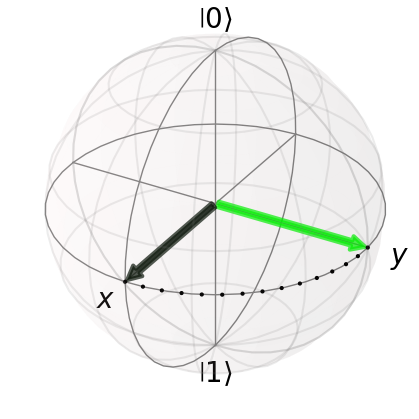

In [17]:
plot_Nstates(states, axis=None, plot_trace_points=True)

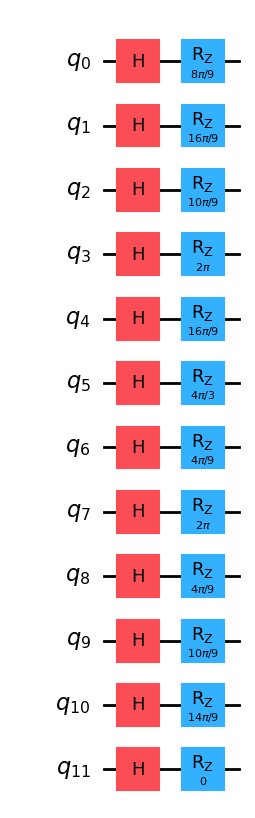

In [18]:
phase_data = [4, 8, 5, 9, 8, 6, 2, 9, 2, 5, 7, 0]
qc = QuantumCircuit(len(phase_data))
for i in range(0, len(phase_data)):
    qc.h(i)
    qc.rz(phase_data[i] * 2 * math.pi / float(max(phase_data)), i)
qc.draw(output="mpl")

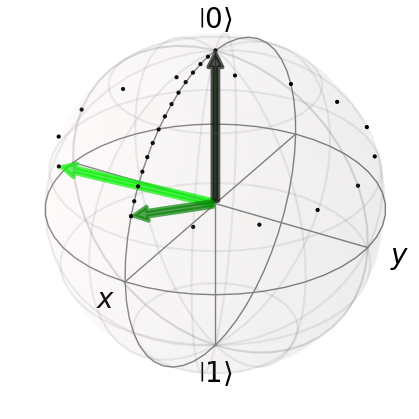

In [19]:
# x1 = theta = 3pi/8
# x2 = phi = 7pi/4

qc = QuantumCircuit(1)
state1 = Statevector.from_instruction(qc)
qc.ry(3 * pi / 8, 0)
state2 = Statevector.from_instruction(qc)
qc.rz(7 * pi / 4, 0)
state3 = Statevector.from_instruction(qc)
states = state1, state2, state3

plot_Nstates(states, axis=None, plot_trace_points=True)

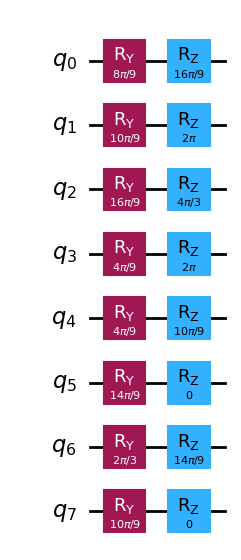

In [20]:
dense_data = [4, 8, 5, 9, 8, 6, 2, 9, 2, 5, 7, 0, 3, 7, 5, 0]
qc = QuantumCircuit(int(len(dense_data) / 2))
entry = 0
for i in range(0, int(len(dense_data) / 2)):
    qc.ry(dense_data[entry] * 2 * math.pi / float(max(dense_data)), i)
    entry += 1
    qc.rz(dense_data[entry] * 2 * math.pi / float(max(dense_data)), i)
    entry += 1
qc.draw(output="mpl")

**Encoding with Built-in Feature Maps**

Efficient SU2

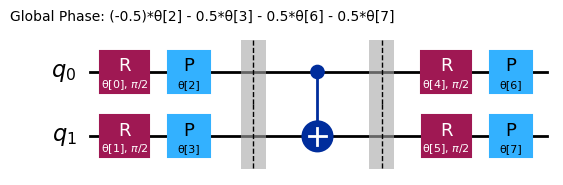

In [21]:
from qiskit.circuit.library import efficient_su2

circuit = efficient_su2(num_qubits=2, reps=1, insert_barriers=True)
circuit.decompose().draw(output="mpl")

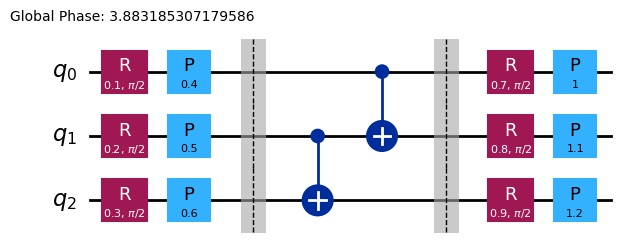

In [22]:
x = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]
circuit = efficient_su2(num_qubits=3, reps=1, insert_barriers=True)
encode = circuit.assign_parameters(x)
encode.decompose().draw(output="mpl")

Z Feature Map

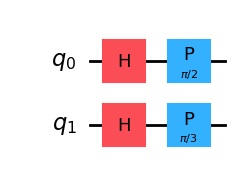

In [23]:
qc0 = QuantumCircuit(1)
qc1 = QuantumCircuit(1)

qc0.h(0)
qc0.p(pi / 2, 0)

qc1.h(0)
qc1.p(pi / 3, 0)

# Combine circuits qc0 and qc1 into 1 circuit
qc = QuantumCircuit(2)
qc.compose(qc0, [0], inplace=True)
qc.compose(qc1, [1], inplace=True)

qc.draw("mpl", scale=1)

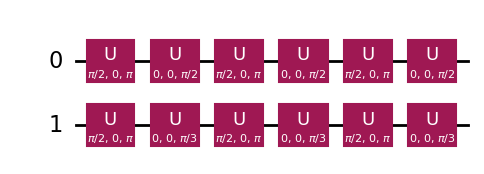

In [25]:
from qiskit.circuit.library import z_feature_map

# x = (pi/2, pi/3)
zfeature_map = z_feature_map(feature_dimension=2, reps=3)
zfeature_map = zfeature_map.assign_parameters([(1 / 2) * pi / 2, (1 / 2) * pi / 3])
zfeature_map.decompose().draw("mpl")

ZZ Feature Map

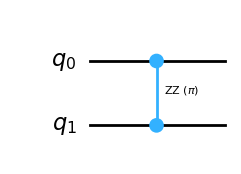

In [26]:
qc = QuantumCircuit(2)
qc.rzz(pi, 0, 1)
qc.draw("mpl", scale=1)

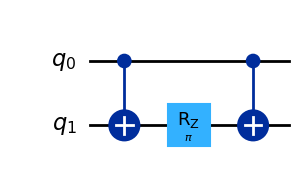

In [27]:
qc.decompose().draw("mpl", scale=1)

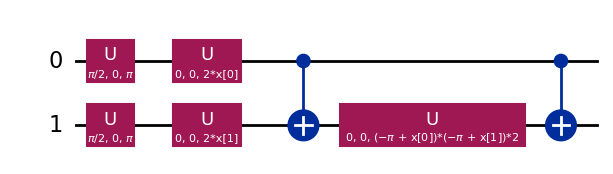

In [28]:
from qiskit.circuit.library import zz_feature_map

feature_dim = 2
zzfeature_map = zz_feature_map(
    feature_dimension=feature_dim, entanglement="linear", reps=1
)
zzfeature_map.decompose(reps=1).draw("mpl", scale=1)

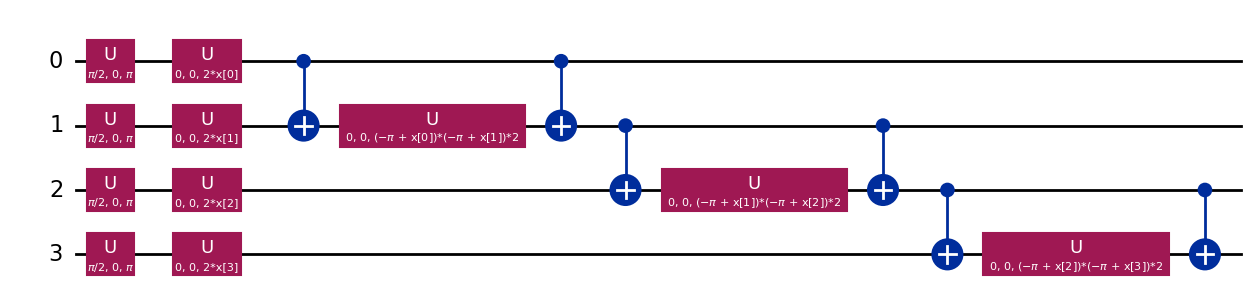

In [29]:
feature_dim = 4
zzfeature_map = zz_feature_map(
    feature_dimension=feature_dim, entanglement="linear", reps=1
)
zzfeature_map.decompose().draw("mpl", scale=1)

Pauli Feature Map

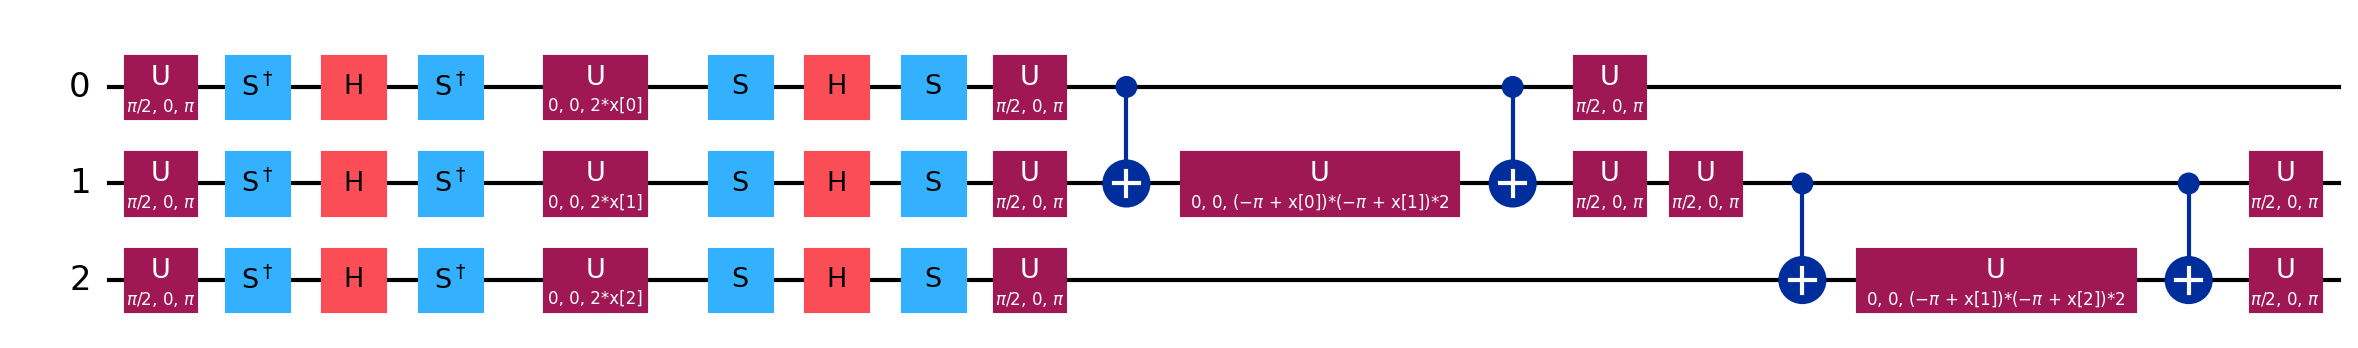

In [30]:
from qiskit.circuit.library import pauli_feature_map

feature_dim = 3
pfmap = pauli_feature_map(
    feature_dimension=feature_dim, entanglement="linear", reps=1, paulis=["Y", "XX"]
)

pfmap.decompose().draw("mpl", scale=1.5)

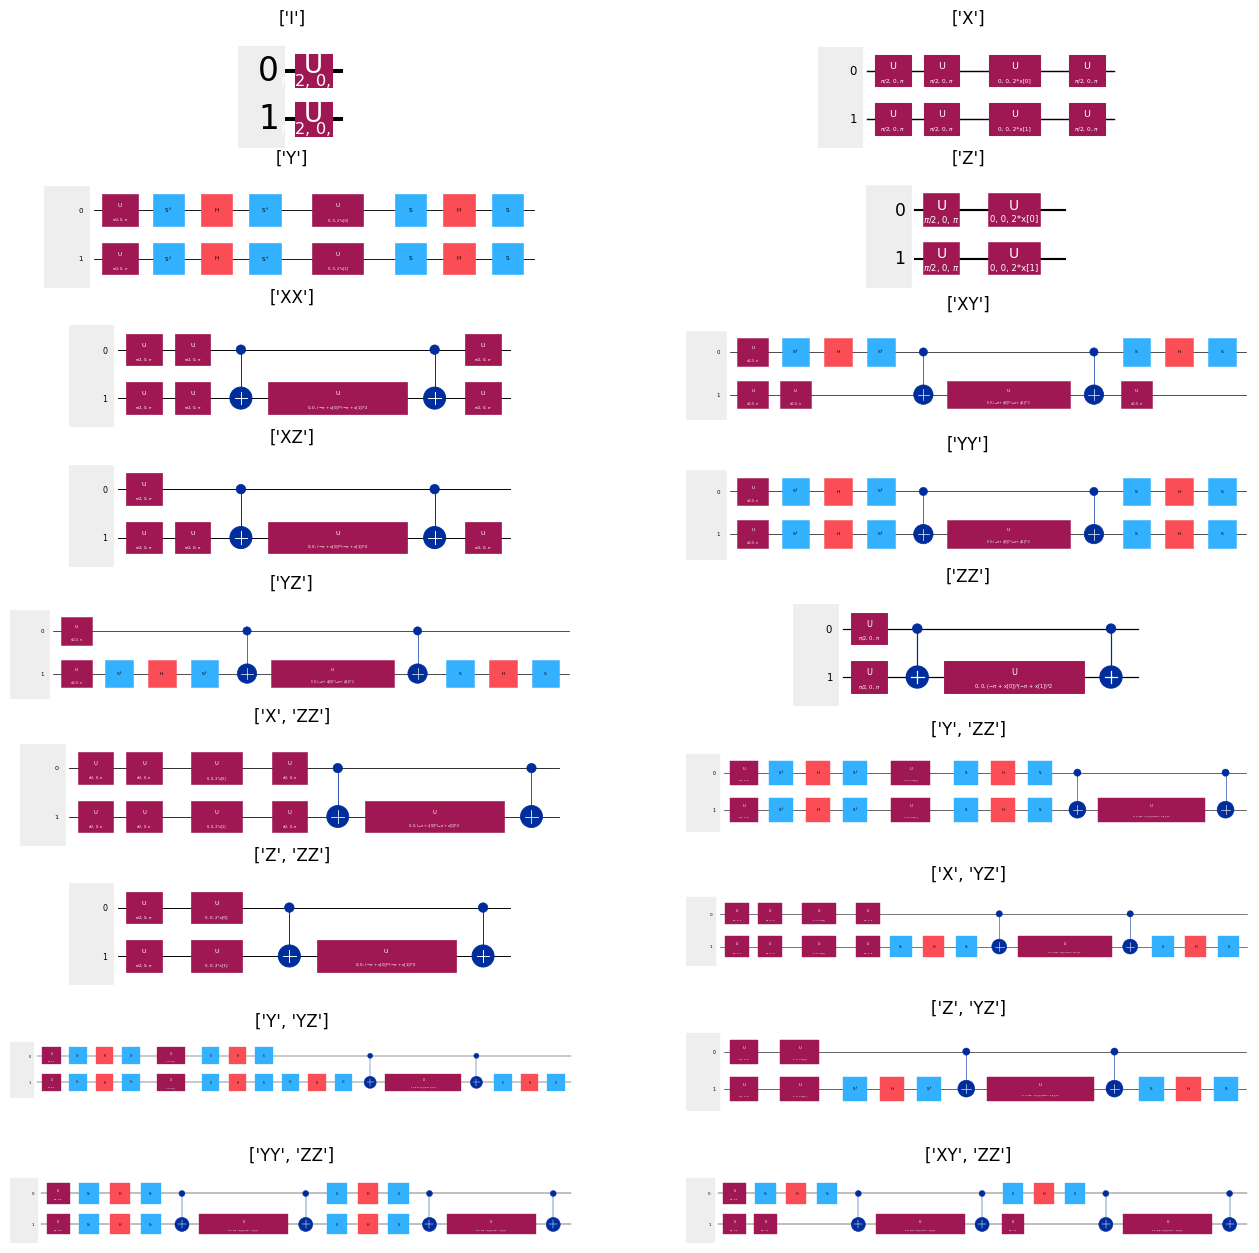

In [31]:
from qiskit.visualization import circuit_drawer
import matplotlib.pyplot as plt

feature_dim = 2
fig, axs = plt.subplots(9, 2)
i_plot = 0
for paulis in [
    ["I"],
    ["X"],
    ["Y"],
    ["Z"],
    ["XX"],
    ["XY"],
    ["XZ"],
    ["YY"],
    ["YZ"],
    ["ZZ"],
    ["X", "ZZ"],
    ["Y", "ZZ"],
    ["Z", "ZZ"],
    ["X", "YZ"],
    ["Y", "YZ"],
    ["Z", "YZ"],
    ["YY", "ZZ"],
    ["XY", "ZZ"],
]:
    pfmap = pauli_feature_map(feature_dimension=feature_dim, paulis=paulis, reps=1)
    circuit_drawer(
        pfmap.decompose(),
        output="mpl",
        style={"backgroundcolor": "#EEEEEE"},
        ax=axs[int((i_plot - i_plot % 2) / 2), i_plot % 2],
    )
    axs[int((i_plot - i_plot % 2) / 2), i_plot % 2].title.set_text(paulis)
    i_plot += 1

fig.set_figheight(16)
fig.set_figwidth(16)

**Review**

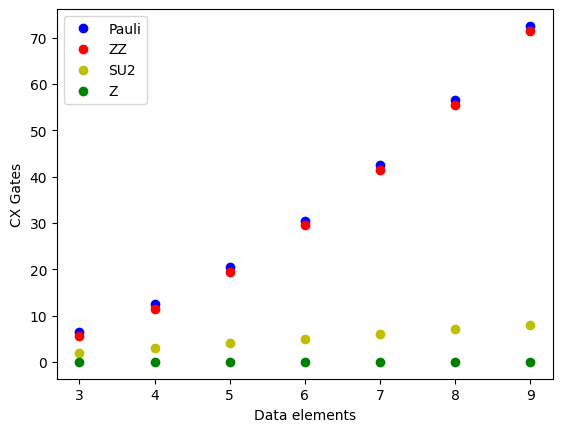

In [32]:
# Initializing parameters and empty lists for depths
x = [0.1, 0.2]
n_data = []
zz2gates = []
su22gates = []
z2gates = []
p2gates = []

# Generating feature maps
for n in range(3, 10):
    x.append(n / 10)
    zzcircuit = zz_feature_map(n, reps=1, insert_barriers=True)
    zcircuit = z_feature_map(n, reps=1, insert_barriers=True)
    su2circuit = efficient_su2(n, reps=1, insert_barriers=True)
    pcircuit = pauli_feature_map(n, reps=1, paulis=["XX"], insert_barriers=True)
    # Getting the cx depths
    zzcx = zzcircuit.decompose().count_ops().get("cx")
    zcx = zcircuit.decompose().count_ops().get("cx")
    su2cx = su2circuit.decompose().count_ops().get("cx")
    pcx = pcircuit.decompose().count_ops().get("cx")

    # Appending the cx gate counts to the lists. We shift the zz and Pauli data points,
    # because they overlap.
    n_data.append(n)
    zz2gates.append(zzcx - 0.5)
    z2gates.append(0)
    su22gates.append(su2cx)
    p2gates.append(pcx + 0.5)

# Plot the output
plt.plot(n_data, p2gates, "bo")
plt.plot(n_data, zz2gates, "ro")
plt.plot(n_data, su22gates, "yo")
plt.plot(n_data, z2gates, "go")
plt.ylabel("CX Gates")
plt.xlabel("Data elements")
plt.legend(["Pauli", "ZZ", "SU2", "Z"])
# plt.suptitle('zz_feature_map(n)')
plt.show()